# ScribeCheck — Master Pipeline

**Author:** Shivanshu Ade   

---

This notebook is the **single controller** for the entire ScribeCheck project.

1. Environment setup
2. Dataset loading and exploration
3. Model loading (pre-trained TrOCR)
4. OCR evaluation (CER / WER)
5. Hybrid similarity scoring
6. Cascade failure analysis
7. Save all results
8. Launch Gradio interface

**MPS Note:** TrOCR fine-tuning is incompatible with Apple Silicon MPS due to a
PyTorch backward-pass limitation (`view` on non-contiguous tensors). Inference
works perfectly on MPS. The pre-trained `trocr-base-handwritten` is already
fine-tuned on IAM by Microsoft, so evaluation and the full pipeline work
without additional training. For custom fine-tuning, use of Google Colab will be required(free T4 GPU).

---
## 1. Environment Setup

In [27]:
import sys, os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset, DataLoader
from jiwer import cer, wer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Device detection: MPS works for inference, not training
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Python: {sys.version.split()[0]}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif device == 'mps':
    print(f'GPU: Apple Silicon (MPS) — inference only, training requires CUDA')
print(f'Project root: {PROJECT_ROOT}')
print('\nEnvironment ready.')

Python: 3.10.19
PyTorch: 2.5.1
Device: mps
GPU: Apple Silicon (MPS) — inference only, training requires CUDA
Project root: /Users/shivanshu_ade/Documents/UF_Assignments/Applied Deep Learning/Project work/ScribeCheck

Environment ready.


---
## 2. Load and Explore IAM Dataset

In [28]:
print('Loading IAM Handwriting Dataset...')
full_dataset = load_dataset('Teklia/IAM-line', split='train')
full_dataset = full_dataset.shuffle(seed=42)

NUM_TEST = 50
test_data = full_dataset.select(range(NUM_TEST))

print(f'Total dataset: {len(full_dataset)}')
print(f'Test subset: {len(test_data)}')
print(f'Features: {list(full_dataset.features.keys())}')
print(f'Sample: "{test_data[0]["text"]}"')

Loading IAM Handwriting Dataset...
Total dataset: 6482
Test subset: 50
Features: ['image', 'text']
Sample: "link together the various West German"


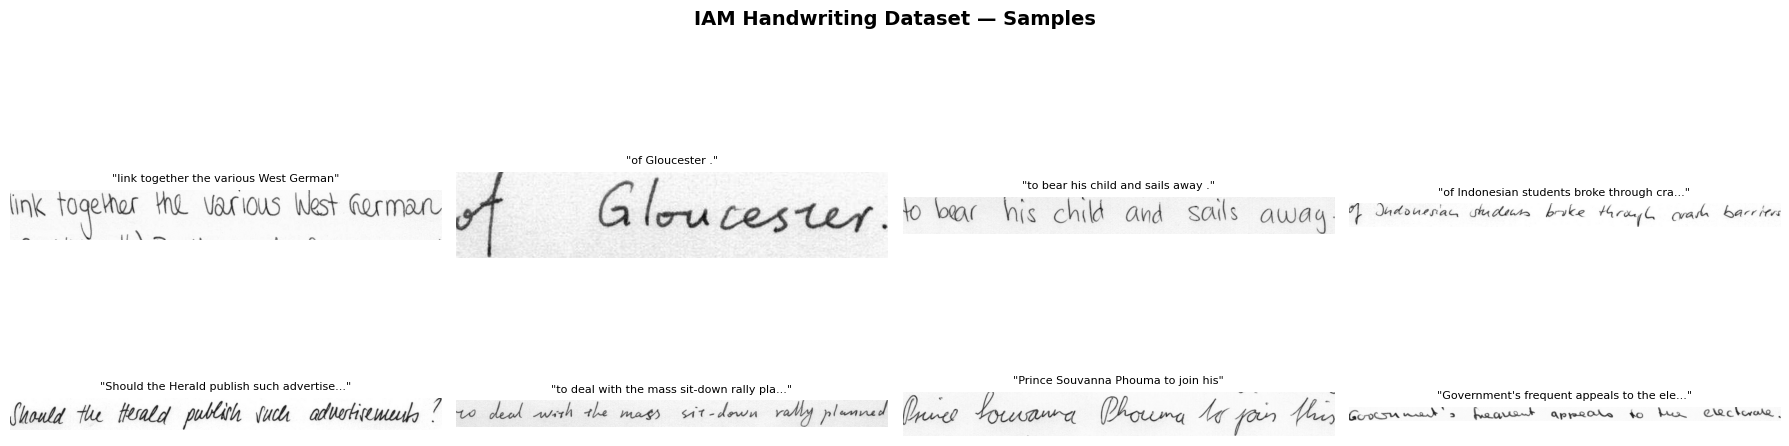

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle('IAM Handwriting Dataset — Samples', fontsize=14, fontweight='bold')
for idx, ax in enumerate(axes.flat):
    s = test_data[idx]
    ax.imshow(s['image'], cmap='gray')
    lbl = s['text']
    ax.set_title(f'"{lbl[:40]}..."' if len(lbl) > 40 else f'"{lbl}"', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

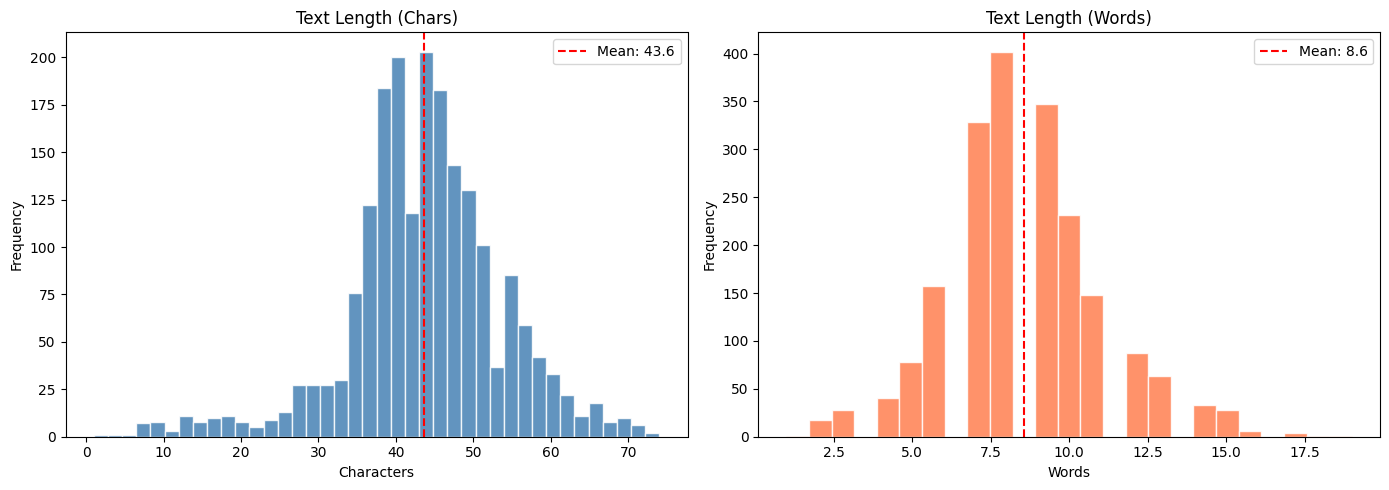

Chars — Mean: 43.6, Range: [1, 74]
Words — Mean: 8.6, Range: [1, 19]


In [30]:
text_lengths = [len(full_dataset[i]['text']) for i in range(min(2000, len(full_dataset)))]
word_counts  = [len(full_dataset[i]['text'].split()) for i in range(min(2000, len(full_dataset)))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(text_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(text_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(text_lengths):.1f}')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Frequency'); axes[0].set_title('Text Length (Chars)'); axes[0].legend()
axes[1].hist(word_counts, bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Mean: {np.mean(word_counts):.1f}')
axes[1].set_xlabel('Words'); axes[1].set_ylabel('Frequency'); axes[1].set_title('Text Length (Words)'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'text_length_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Chars — Mean: {np.mean(text_lengths):.1f}, Range: [{min(text_lengths)}, {max(text_lengths)}]')
print(f'Words — Mean: {np.mean(word_counts):.1f}, Range: [{min(word_counts)}, {max(word_counts)}]')

---
## 3. Load Pre-Trained TrOCR Model

The `microsoft/trocr-base-handwritten` model is already fine-tuned on IAM by Microsoft,
achieving ~4.4% CER. We use it directly for inference — this works on **all devices**
including MPS (Apple Silicon).

In [31]:
MODEL_NAME = 'microsoft/trocr-base-handwritten'

print(f'Loading {MODEL_NAME}...')
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f'Model loaded on {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loading microsoft/trocr-base-handwritten...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on mps
Parameters: 333,921,792


---
## 4. OCR Evaluation — CER & WER
---

**Published baseline:** `trocr-base-handwritten` on full IAM: ~4.4% CER

In [32]:
model.eval()
test_predictions, test_references = [], []

print(f'Running inference on {len(test_data)} test samples on {device}...')
for i in tqdm(range(len(test_data))):
    sample = test_data[i]
    image = sample['image'].convert('RGB')
    pv = processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pv, max_length=128)
    test_predictions.append(processor.batch_decode(ids, skip_special_tokens=True)[0])
    test_references.append(sample['text'])

print('Inference complete.')

Running inference on 50 test samples on mps...


100%|██████████| 50/50 [00:16<00:00,  3.06it/s]

Inference complete.


In [33]:
import os, sys

print("Current dir:", os.getcwd())
print("src/ exists here:", os.path.exists('src'))
print("src/ exists in parent:", os.path.exists('../src'))
print("\nCurrent dir contents:")
for item in sorted(os.listdir('.')):
    print(f"  {item}")
print("\nsys.path:")
for p in sys.path[:5]:
    print(f"  {p}")

Current dir: /Users/shivanshu_ade/Documents/UF_Assignments/Applied Deep Learning/Project work/ScribeCheck/notebooks
src/ exists here: False
src/ exists in parent: True

Current dir contents:
  train_and_evaluate.ipynb

sys.path:
  /Users/shivanshu_ade/Documents/UF_Assignments/Applied Deep Learning/Project work/ScribeCheck
  /Users/shivanshu_ade/Documents/UF_Assignments/Applied Deep Learning/Project work/ScribeCheck
  /Users/shivanshu_ade/Documents/anaconda3/envs/deep-learning/lib/python310.zip
  /Users/shivanshu_ade/Documents/anaconda3/envs/deep-learning/lib/python3.10
  /Users/shivanshu_ade/Documents/anaconda3/envs/deep-learning/lib/python3.10/lib-dynload


In [34]:
import os
scribecheck_dir = os.path.abspath('..')
print(f"ScribeCheck contents:")
for item in sorted(os.listdir(scribecheck_dir)):
    print(f"  {item}")
    # Shows subdirectory contents too
    full_path = os.path.join(scribecheck_dir, item)
    if os.path.isdir(full_path) and not item.startswith('.'):
        for sub in sorted(os.listdir(full_path)):
            print(f"    {sub}")

ScribeCheck contents:
  .DS_Store
  .git
  .gitignore
  README.md
  notebooks
    train_and_evaluate.ipynb
  requirements.txt
  results
    cascade_analysis.png
    cer_vs_similarity.png
    cer_wer_distributions.png
    final_results.json
    metrics_correlation.png
    sample_iam_image.png
    sample_images.png
    test_predictions_visual.png
    test_results.csv
    text_length_distributions.png
  src
    __init__.py
    __pycache__
    evaluation.py
    ocr_engine.py
    preprocessing.py
    similarity.py
    train.py
  train_and_evaluate.ipynb
  ui
    app.py


In [35]:
from src.evaluation import evaluate_ocr_batch

ocr_results = evaluate_ocr_batch(test_predictions, test_references)
cer_scores = [r['cer'] for r in ocr_results['per_sample']]
wer_scores = [r['wer'] for r in ocr_results['per_sample']]

print('=' * 60)
print(f'OCR EVALUATION ({ocr_results["num_samples"]} samples)')
print('=' * 60)
print(f'Mean CER: {ocr_results["mean_cer"]:.4f} ({ocr_results["mean_cer"]*100:.2f}%)')
print(f'Mean WER: {ocr_results["mean_wer"]:.4f} ({ocr_results["mean_wer"]*100:.2f}%)')
print(f'Published baseline (trocr-base, full IAM): ~4.4% CER')
print(f'\n{"#":<4} {"CER":>7} {"WER":>7}  {"Ground Truth":<35} {"Prediction":<35}')
print('-' * 92)
for i in range(min(15, len(test_predictions))):
    gt = test_references[i][:33] + '..' if len(test_references[i]) > 35 else test_references[i]
    pr = test_predictions[i][:33] + '..' if len(test_predictions[i]) > 35 else test_predictions[i]
    print(f'{i:<4} {cer_scores[i]:>7.4f} {wer_scores[i]:>7.4f}  {gt:<35} {pr:<35}')

OCR EVALUATION (50 samples)
Mean CER: 0.0072 (0.72%)
Mean WER: 0.0244 (2.44%)
Published baseline (trocr-base, full IAM): ~4.4% CER

#        CER     WER  Ground Truth                        Prediction                         
--------------------------------------------------------------------------------------------
0     0.0270  0.1667  link together the various West Ge.. ink together the various West Ger..
1     0.0000  0.0000  of Gloucester .                     of Gloucester .                    
2     0.0000  0.0000  to bear his child and sails away .  to bear his child and sails away . 
3     0.0000  0.0000  of Indonesian students broke thro.. of Indonesian students broke thro..
4     0.0000  0.0000  Should the Herald publish such ad.. Should the Herald publish such ad..
5     0.0000  0.0000  to deal with the mass sit-down ra.. to deal with the mass sit-down ra..
6     0.0882  0.3333  Prince Souvanna Phouma to join his  Prince Souesanna Phouma to join t..
7     0.0000  0.0000  G

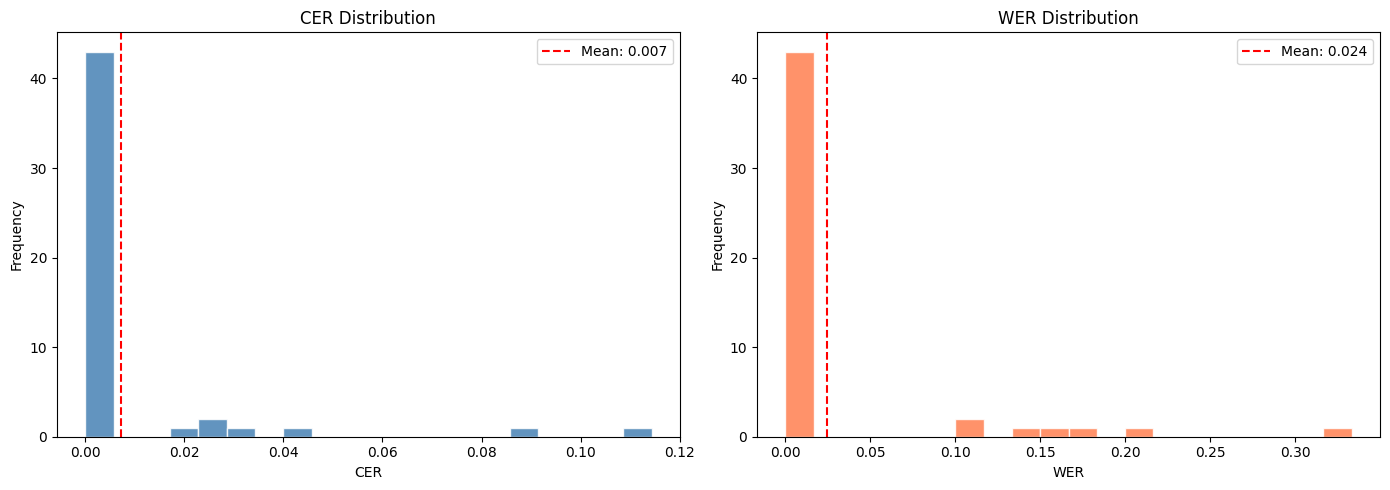

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cer_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(cer_scores), color='red', linestyle='--', label=f'Mean: {np.mean(cer_scores):.3f}')
axes[0].set_xlabel('CER'); axes[0].set_ylabel('Frequency'); axes[0].set_title('CER Distribution'); axes[0].legend()
axes[1].hist(wer_scores, bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(wer_scores), color='red', linestyle='--', label=f'Mean: {np.mean(wer_scores):.3f}')
axes[1].set_xlabel('WER'); axes[1].set_ylabel('Frequency'); axes[1].set_title('WER Distribution'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_wer_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

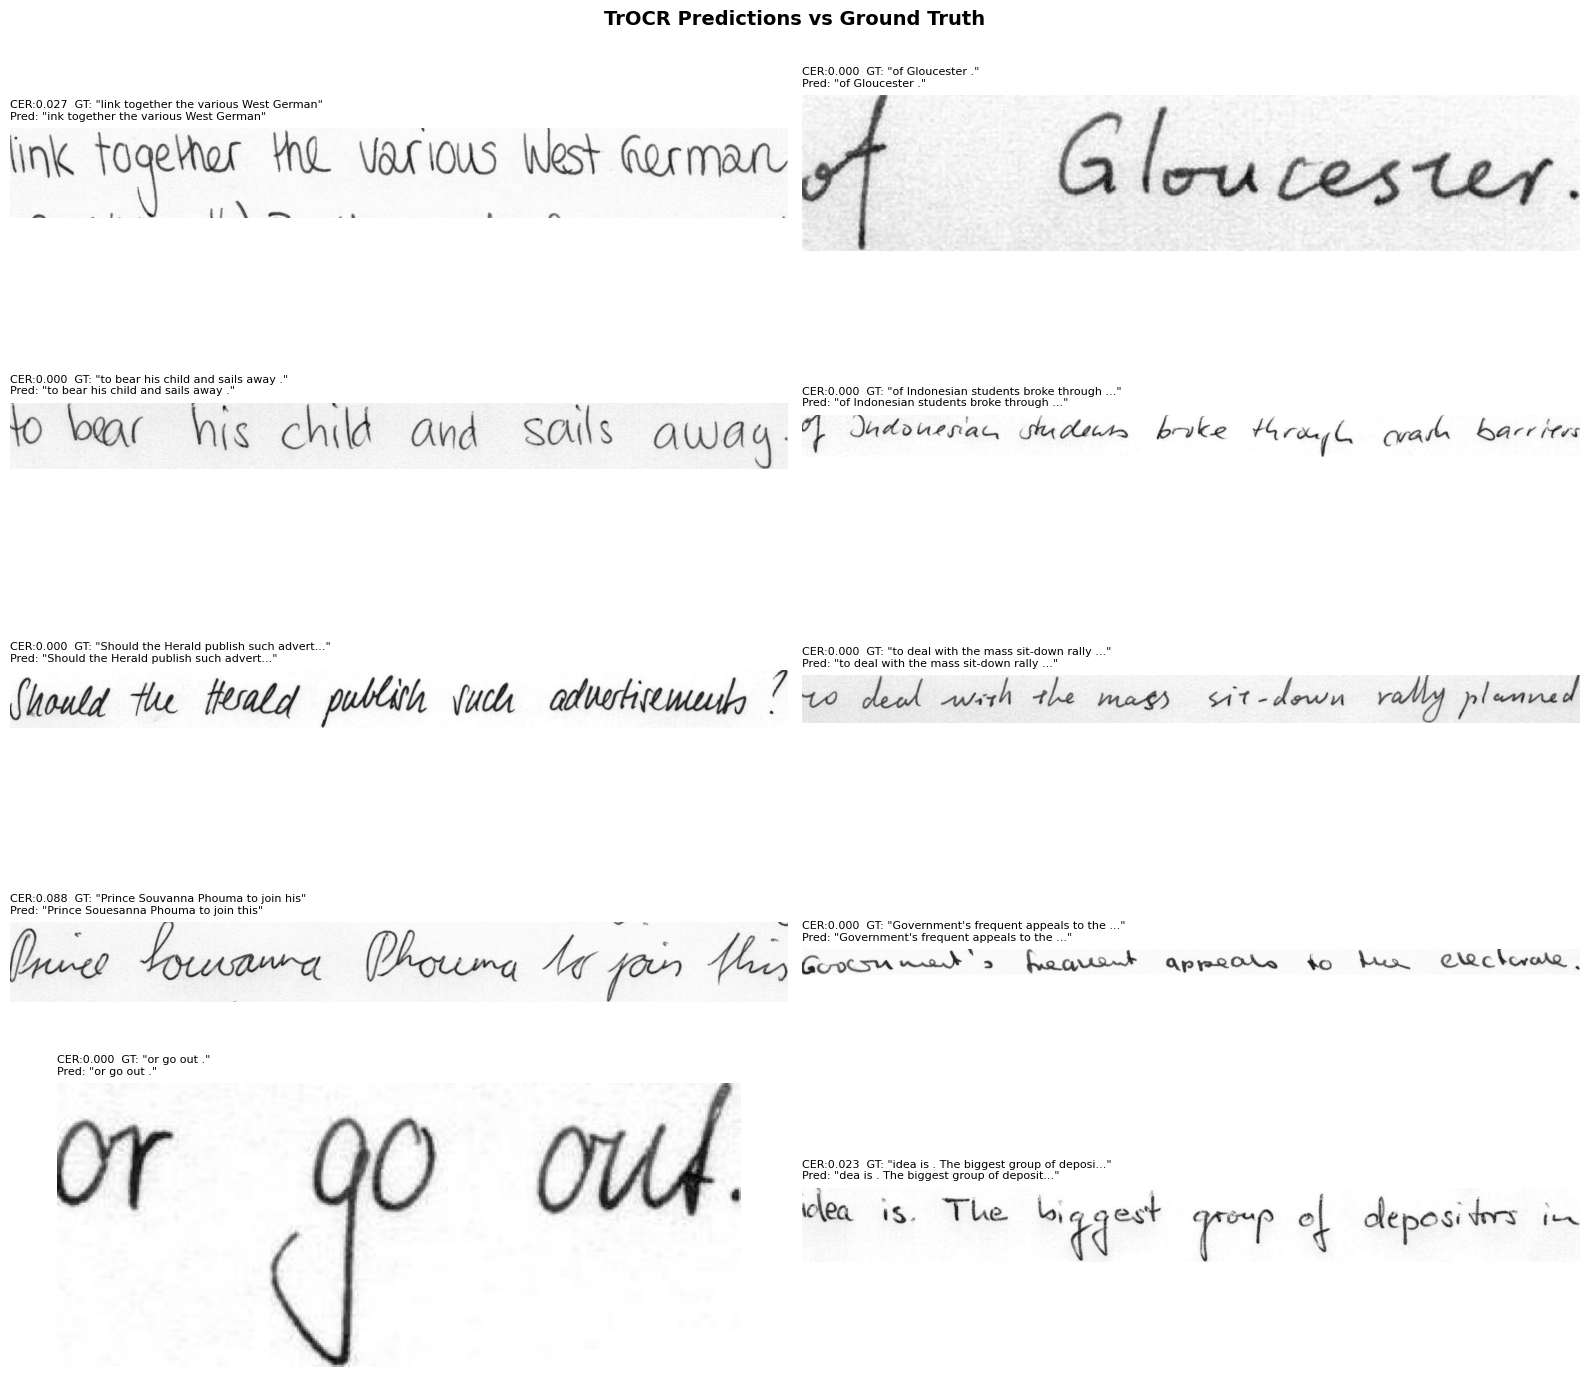

In [37]:
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
fig.suptitle('TrOCR Predictions vs Ground Truth', fontsize=14, fontweight='bold')
for idx in range(10):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    ax.imshow(test_data[idx]['image'], cmap='gray')
    gt_s = test_references[idx] if len(test_references[idx]) <= 40 else test_references[idx][:37] + '...'
    pr_s = test_predictions[idx] if len(test_predictions[idx]) <= 40 else test_predictions[idx][:37] + '...'
    ax.set_title(f'CER:{cer_scores[idx]:.3f}  GT: "{gt_s}"\nPred: "{pr_s}"', fontsize=8, ha='left', x=0)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test_predictions_visual.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Hybrid Similarity Scoring

In [38]:
!pip install sentence-transformers

In [39]:
from src.similarity import compute_hybrid_score

print('Computing hybrid similarity scores...')
sim_results = [compute_hybrid_score(p, r, return_breakdown=True) for p, r in zip(test_predictions, test_references)]

df = pd.DataFrame({
    'reference': test_references, 'prediction': test_predictions,
    'cer': cer_scores, 'wer': wer_scores,
    'levenshtein': [s['levenshtein'] for s in sim_results],
    'bleu': [s['bleu'] for s in sim_results],
    'cosine': [s['cosine'] for s in sim_results],
    'combined': [s['combined_score'] for s in sim_results],
})

print('\nSIMILARITY SCORING SUMMARY')
print('=' * 60)
print(df[['cer','wer','levenshtein','bleu','cosine','combined']].describe().round(4).to_string())
print(f'\nMean Combined: {df["combined"].mean():.4f}')

Computing hybrid similarity scores...

SIMILARITY SCORING SUMMARY
           cer      wer  levenshtein     bleu   cosine  combined
count  50.0000  50.0000      50.0000  50.0000  50.0000   50.0000
mean    0.0072   0.0244       0.9931   0.9273   0.9778    0.9680
std     0.0218   0.0667       0.0209   0.1811   0.0712    0.0785
min     0.0000   0.0000       0.8919   0.2171   0.6806    0.6432
25%     0.0000   0.0000       1.0000   1.0000   1.0000    1.0000
50%     0.0000   0.0000       1.0000   1.0000   1.0000    1.0000
75%     0.0000   0.0000       1.0000   1.0000   1.0000    1.0000
max     0.1143   0.3333       1.0000   1.0000   1.0000    1.0000

Mean Combined: 0.9680


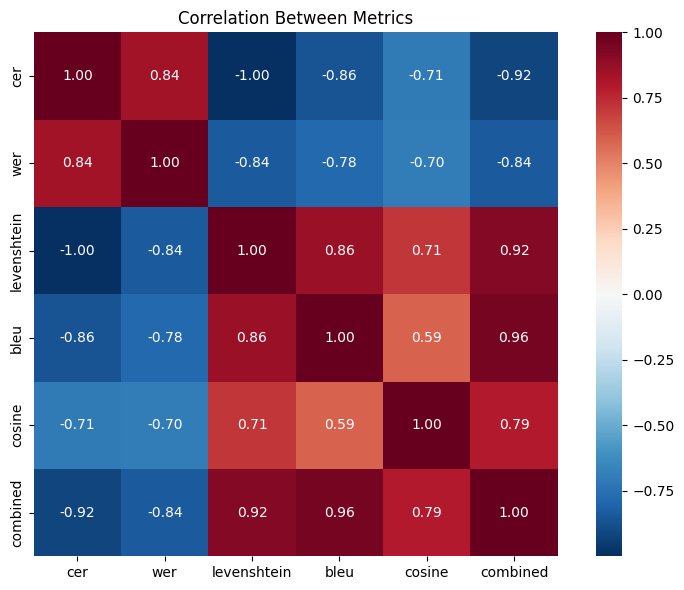

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[['cer','wer','levenshtein','bleu','cosine','combined']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Between Metrics')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'metrics_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

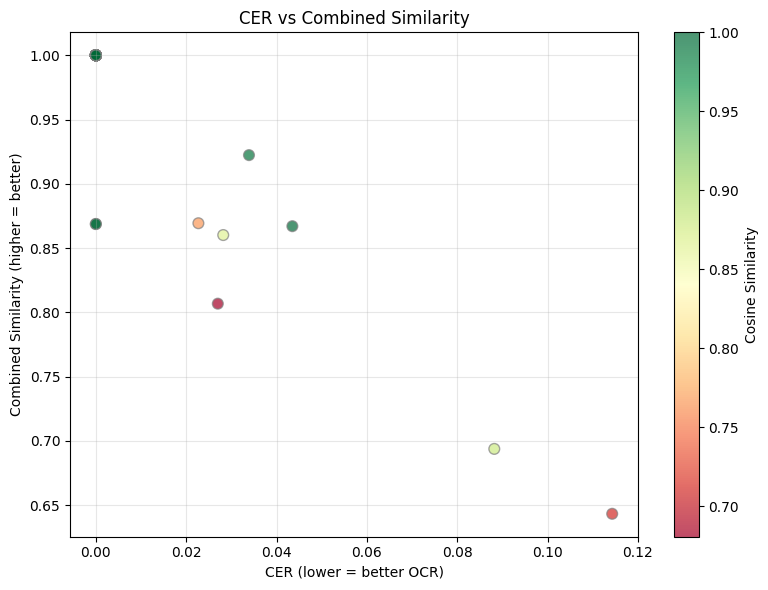

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df['cer'], df['combined'], c=df['cosine'], cmap='RdYlGn', alpha=0.7, edgecolors='gray', s=60)
ax.set_xlabel('CER (lower = better OCR)'); ax.set_ylabel('Combined Similarity (higher = better)')
ax.set_title('CER vs Combined Similarity'); plt.colorbar(sc, label='Cosine Similarity'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_vs_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cascade Failure Analysis
---
Stratify similarity scores by OCR quality to isolate transcription errors from content mismatches.


In [42]:
from src.evaluation import cascade_analysis

cascade = cascade_analysis(test_predictions, test_references, cer_threshold=0.1)

print('CASCADE FAILURE ANALYSIS')
print('=' * 60)
for label, key in [('Good OCR (CER <= 0.1)', 'good_ocr'), ('Poor OCR (CER > 0.1)', 'poor_ocr')]:
    g = cascade[key]
    print(f'\n{label}:')
    if g['count'] > 0:
        print(f'  Samples: {g["count"]}, Mean CER: {g["mean_cer"]:.4f}, Mean Combined: {g["mean_combined"]:.4f}')
        print(f'  Levenshtein: {g["mean_levenshtein"]:.4f}, BLEU: {g["mean_bleu"]:.4f}, Cosine: {g["mean_cosine"]:.4f}')
    else:
        print('  No samples.')

CASCADE FAILURE ANALYSIS

Good OCR (CER <= 0.1):
  Samples: 49, Mean CER: 0.0050, Mean Combined: 0.9746
  Levenshtein: 0.9951, BLEU: 0.9406, Cosine: 0.9833

Poor OCR (CER > 0.1):
  Samples: 1, Mean CER: 0.1143, Mean Combined: 0.6432
  Levenshtein: 0.8919, BLEU: 0.2749, Cosine: 0.7101


/var/folders/6q/hz_vnm052s3gxv9p7n5w9nkc0000gn/T/ipykernel_2350/3029058234.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True)


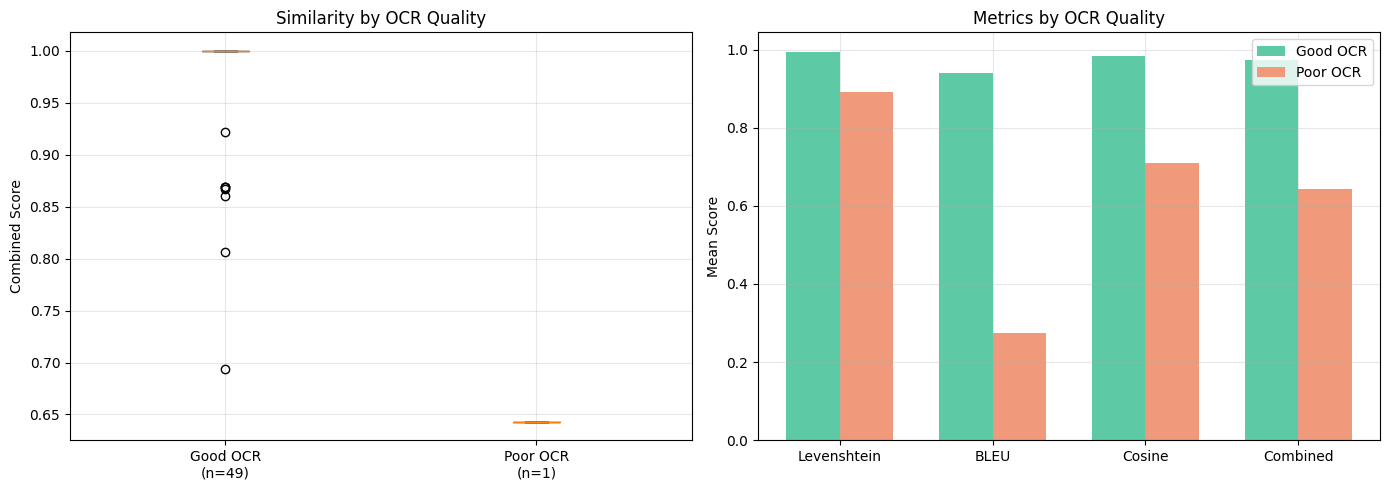

In [43]:
good_c = [s['combined_score'] for s in cascade['good_ocr_samples']]
poor_c = [s['combined_score'] for s in cascade['poor_ocr_samples']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_box, labels_box = [], []
if good_c: data_box.append(good_c); labels_box.append(f'Good OCR\n(n={len(good_c)})')
if poor_c: data_box.append(poor_c); labels_box.append(f'Poor OCR\n(n={len(poor_c)})')
if data_box:
    bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#5DCAA5','#F0997B']): patch.set_facecolor(c)
axes[0].set_ylabel('Combined Score'); axes[0].set_title('Similarity by OCR Quality'); axes[0].grid(alpha=0.3)

names = ['Levenshtein','BLEU','Cosine','Combined']
keys_ = ['mean_levenshtein','mean_bleu','mean_cosine','mean_combined']
x = np.arange(len(names)); w = 0.35
if cascade['good_ocr']['count'] > 0:
    axes[1].bar(x-w/2, [cascade['good_ocr'].get(k,0) or 0 for k in keys_], w, label='Good OCR', color='#5DCAA5')
if cascade['poor_ocr']['count'] > 0:
    axes[1].bar(x+w/2, [cascade['poor_ocr'].get(k,0) or 0 for k in keys_], w, label='Poor OCR', color='#F0997B')
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel('Mean Score'); axes[1].set_title('Metrics by OCR Quality'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cascade_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Save All Results
---

In [44]:
final_results = {
    'model': MODEL_NAME,
    'device': device,
    'test_samples': NUM_TEST,
    'ocr': {'mean_cer': ocr_results['mean_cer'], 'mean_wer': ocr_results['mean_wer'], 'baseline_cer': 0.044},
    'similarity': {
        'mean_combined': round(df['combined'].mean(), 4),
        'mean_levenshtein': round(df['levenshtein'].mean(), 4),
        'mean_bleu': round(df['bleu'].mean(), 4),
        'mean_cosine': round(df['cosine'].mean(), 4),
    },
    'cascade': {
        'good_ocr_count': cascade['good_ocr']['count'],
        'poor_ocr_count': cascade['poor_ocr']['count'],
        'good_combined': cascade['good_ocr'].get('mean_combined'),
        'poor_combined': cascade['poor_ocr'].get('mean_combined'),
    }
}

with open(os.path.join(RESULTS_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)
df.to_csv(os.path.join(RESULTS_DIR, 'test_results.csv'), index=False)

print('All results saved to results/:')
for fname in sorted(os.listdir(RESULTS_DIR)):
    if not fname.startswith('.'): print(f'  {fname}')

All results saved to results/:
  cascade_analysis.png
  cer_vs_similarity.png
  cer_wer_distributions.png
  final_results.json
  metrics_correlation.png
  sample_iam_image.png
  sample_images.png
  test_predictions_visual.png
  test_results.csv
  text_length_distributions.png


---
## 8. Launch Gradio Interface
---

In [45]:
!pip install gradio

In [46]:
import gradio as gr
from src.evaluation import compute_cer, compute_wer

def evaluate_handwriting(image, reference_text, w_lev, w_bleu, w_cos):
    if image is None: return 'No image provided.', '', '', '', '', '', ''
    if not reference_text or not reference_text.strip(): return 'Please enter reference text.', '', '', '', '', '', ''
    pil_image = Image.fromarray(image).convert('RGB') if isinstance(image, np.ndarray) else image.convert('RGB')
    pv = processor(images=pil_image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pv, max_length=128)
    transcription = processor.batch_decode(ids, skip_special_tokens=True)[0]
    s_cer = compute_cer(transcription, reference_text)
    s_wer = compute_wer(transcription, reference_text)
    total_w = w_lev + w_bleu + w_cos
    if total_w == 0: total_w = 1.0
    weights = {'levenshtein': w_lev/total_w, 'bleu': w_bleu/total_w, 'cosine': w_cos/total_w}
    sim = compute_hybrid_score(transcription, reference_text, weights=weights, return_breakdown=True)
    return (transcription, f'{s_cer:.4f} ({s_cer*100:.2f}%)', f'{s_wer:.4f} ({s_wer*100:.2f}%)',
            f'{sim["levenshtein"]:.4f}', f'{sim["bleu"]:.4f}', f'{sim["cosine"]:.4f}', f'{sim["combined_score"]:.4f}')

with gr.Blocks(title='ScribeCheck', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# ScribeCheck — Handwritten Text Evaluation\nUpload a handwritten image and enter reference text.')
    with gr.Row():
        with gr.Column():
            gr.Markdown('### Input')
            img_in  = gr.Image(type='pil', label='Handwritten Image')
            ref_in  = gr.Textbox(label='Reference Text', placeholder='Enter expected text...', lines=3)
            gr.Markdown('#### Weights')
            with gr.Row():
                wl = gr.Slider(0,1,value=0.35,step=0.05,label='Levenshtein')
                wb = gr.Slider(0,1,value=0.30,step=0.05,label='BLEU')
                wc = gr.Slider(0,1,value=0.35,step=0.05,label='Cosine')
            btn = gr.Button('Run Evaluation', variant='primary')
        with gr.Column():
            gr.Markdown('### Results')
            t_out = gr.Textbox(label='OCR Transcription', interactive=False)
            with gr.Row():
                cer_o = gr.Textbox(label='CER', interactive=False)
                wer_o = gr.Textbox(label='WER', interactive=False)
            gr.Markdown('#### Similarity')
            with gr.Row():
                lev_o = gr.Textbox(label='Levenshtein', interactive=False)
                blu_o = gr.Textbox(label='BLEU', interactive=False)
                cos_o = gr.Textbox(label='Cosine', interactive=False)
            comb_o = gr.Textbox(label='Combined Score (0-1)', interactive=False)
    btn.click(fn=evaluate_handwriting, inputs=[img_in,ref_in,wl,wb,wc], outputs=[t_out,cer_o,wer_o,lev_o,blu_o,cos_o,comb_o])

print('Launching Gradio...')
demo.launch(inline=True, share=False)

/var/folders/6q/hz_vnm052s3gxv9p7n5w9nkc0000gn/T/ipykernel_2350/3398046094.py:21: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title='ScribeCheck', theme=gr.themes.Soft()) as demo:


Launching Gradio...
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [47]:
# Save a test image for Gradio demo
test_data[0]['image'].save('../results/sample_iam_image.png')
print(f'Reference text: "{test_data[0]["text"]}"')

Reference text: "link together the various West German"


---
## Summary
---
This notebook ran the **complete ScribeCheck pipeline**:

1. **Dataset** — IAM loaded and explored
2. **Model** — Pre-trained TrOCR loaded (MPS/CUDA/CPU compatible)
3. **OCR Evaluation** — CER/WER on 50 test samples, compared to published baselines
4. **Similarity** — Hybrid scoring (Levenshtein + BLEU + Cosine)
5. **Cascade Analysis** — Stratified by OCR quality
6. **Results** — All metrics and plots saved
7. **Gradio UI** — Interactive interface launched

### Hardware Note
TrOCR fine-tuning requires CUDA (e.g., Google Colab). MPS (Apple Silicon) works for inference but not training due to a PyTorch backward-pass limitation. The pre-trained model is already fine-tuned on IAM by Microsoft (~4.4% CER baseline) 